# 02 - Assumptions and EDA

### Austin Melendez & Sara Bruggman
###### Last Updated: 5/1/2026 11:14am

This notebook loads the cleaned datasets from `01-preprocessing.ipynb`, summarizes the data numerically, and creates diagnostic plots for the modeling assumptions.


In [ ]:
suppressPackageStartupMessages({
  library(tidyverse)
})

processed_dir <- file.path("./data/")

if (file.exists(file.path(processed_dir, "analysis_data.rds"))) {
  analysis_data <- readRDS(file.path(processed_dir, "analysis_data.rds"))
  survey_clean <- analysis_data$survey_clean
  pre_survey_clean <- analysis_data$pre_survey_clean
  post_survey_clean <- analysis_data$post_survey_clean
  matched_change <- analysis_data$matched_change
} else {
  survey_clean <- read_csv(file.path(processed_dir, "survey_clean.csv"))
  pre_survey_clean <- read_csv(file.path(processed_dir, "pre_survey_clean.csv"))
  post_survey_clean <- read_csv(file.path(processed_dir, "post_survey_clean.csv"))
  matched_change <- read_csv(file.path(processed_dir, "matched_change.csv"))
}

survey_clean <- survey_clean %>%
  mutate(
    Survey = factor(Survey, levels = c("Pre", "Post")),
    STEM = factor(STEM, levels = c("STEM", "Non-STEM")),
    Condition = factor(Condition, levels = c("Control", "Intervention"))
  )

matched_change <- matched_change %>%
  mutate(
    STEM = factor(STEM, levels = c("STEM", "Non-STEM")),
    Condition = factor(Condition, levels = c("Control", "Intervention"))
  )


## Numerical Summary


In [ ]:
summary(survey_clean)

survey_clean %>%
  group_by(Survey, Condition, STEM) %>%
  summarise(
    n = n(),
    mean_J = mean(J_total, na.rm = TRUE),
    sd_J = sd(J_total, na.rm = TRUE),
    median_J = median(J_total, na.rm = TRUE),
    iqr_J = IQR(J_total, na.rm = TRUE),
    mean_T = mean(T_total, na.rm = TRUE),
    sd_T = sd(T_total, na.rm = TRUE),
    median_T = median(T_total, na.rm = TRUE),
    iqr_T = IQR(T_total, na.rm = TRUE),
    .groups = "drop"
  )

matched_change %>%
  group_by(Condition, STEM) %>%
  summarise(
    n = n(),
    mean_J_change = mean(J_change, na.rm = TRUE),
    sd_J_change = sd(J_change, na.rm = TRUE),
    median_J_change = median(J_change, na.rm = TRUE),
    mean_T_change = mean(T_change, na.rm = TRUE),
    sd_T_change = sd(T_change, na.rm = TRUE),
    median_T_change = median(T_change, na.rm = TRUE),
    .groups = "drop"
  )


     DID #        Survey           Condition   Intervention v Control
 Min.   :  1.0   Pre :222   Control     :252   Length:444            
 1st Qu.: 58.0   Post:222   Intervention:192   Class :character      
 Median :116.5                                 Mode  :character      
 Mean   :116.6                                                       
 3rd Qu.:176.0                                                       
 Max.   :231.0                                                       
 First Generation Status    Gender          Transfer Student  
 Length:444              Length:444         Length:444        
 Class :character        Class :character   Class :character  
 Mode  :character        Mode  :character   Mode  :character  
                                                              
                                                              
                                                              
 Upper v Lower      Race/Ethnicity     Class Level           Major   

Survey,Condition,STEM,n,mean_J,sd_J,median_J,iqr_J,mean_T,sd_T,median_T,iqr_T
<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Pre,Control,STEM,47,76.06383,10.046423,76,15.0,47.65957,6.359781,49,10.0
Pre,Control,Non-STEM,79,74.89873,9.256453,75,14.0,47.24051,5.835820,47,7.0
Pre,Intervention,STEM,53,75.60377,9.068838,77,11.0,48.16981,5.941173,49,9.0
Pre,Intervention,Non-STEM,43,77.20930,8.833265,79,12.5,48.93023,5.452808,49,7.0
Post,Control,STEM,47,82.59574,9.970957,83,17.0,49.46809,6.409406,51,10.5
Post,Control,Non-STEM,79,79.83544,11.133721,81,14.5,48.51899,6.084576,49,9.0
Post,Intervention,STEM,53,82.41509,10.208281,85,11.0,49.26415,6.622081,51,7.0
Post,Intervention,Non-STEM,43,83.37209,9.263403,84,10.5,50.00000,5.424811,50,7.5


Condition,STEM,n,mean_J_change,sd_J_change,median_J_change,mean_T_change,sd_T_change,median_T_change
<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Control,STEM,47,6.531915,6.476886,6,1.808511,4.391881,1
Control,Non-STEM,79,4.936709,8.419059,5,1.278481,4.698436,1
Intervention,STEM,53,6.811321,6.653676,5,1.094340,4.161472,1
Intervention,Non-STEM,43,6.162791,6.658079,5,1.069767,3.487361,1


## Cell Counts and Pairing Checks


In [ ]:
table(matched_change$STEM, matched_change$Condition)

table(survey_clean$Survey)

table(survey_clean$Survey, survey_clean$Condition, survey_clean$STEM)

matched_change %>%
  summarise(
    n_participants = n(),
    missing_condition = sum(is.na(Condition)),
    missing_stem = sum(is.na(STEM)),
    missing_J_change = sum(is.na(J_change)),
    missing_T_change = sum(is.na(T_change))
  )


          
           Control Intervention
  STEM          47           53
  Non-STEM      79           43


 Pre Post 
 222  222 

, ,  = STEM

      
       Control Intervention
  Pre       47           53
  Post      47           53

, ,  = Non-STEM

      
       Control Intervention
  Pre       79           43
  Post      79           43


n_participants,missing_condition,missing_stem,missing_J_change,missing_T_change
<int>,<int>,<int>,<int>,<int>
222,0,0,0,0


## Distribution Plots


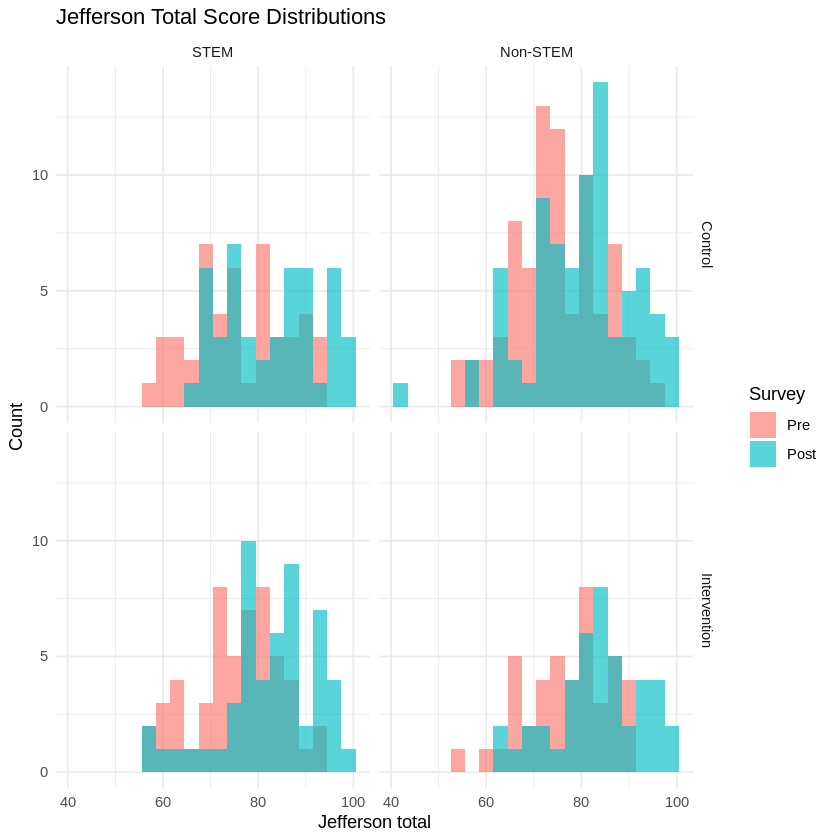

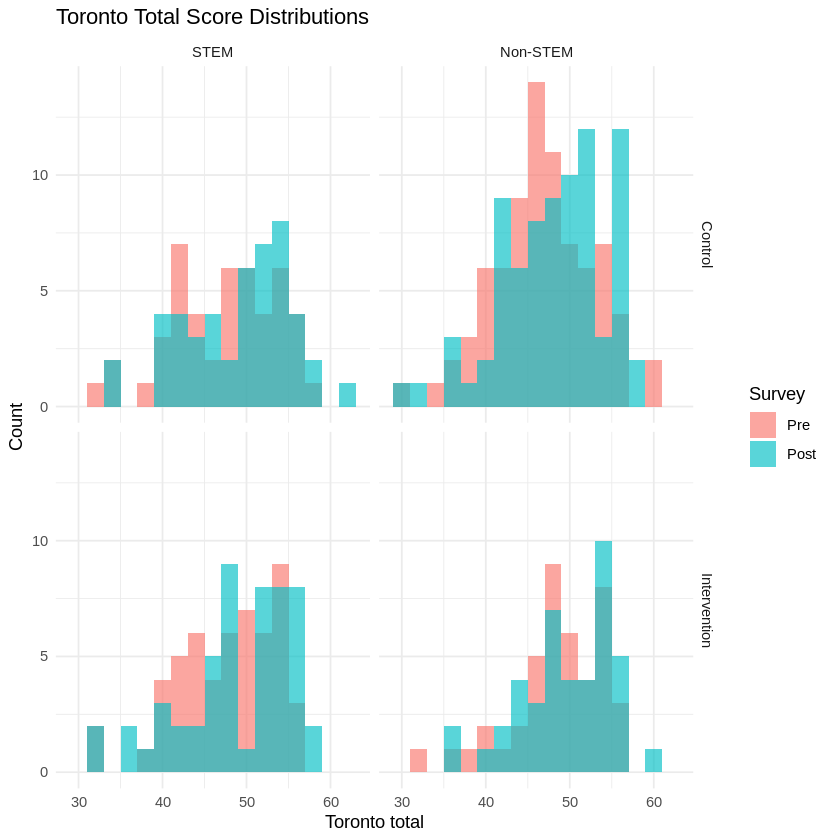

In [ ]:
ggplot(survey_clean, aes(x = J_total, fill = Survey)) +
  geom_histogram(binwidth = 3, alpha = 0.65, position = "identity") +
  facet_grid(Condition ~ STEM) +
  labs(title = "Jefferson Total Score Distributions", x = "Jefferson total", y = "Count") +
  theme_minimal()

ggplot(survey_clean, aes(x = T_total, fill = Survey)) +
  geom_histogram(binwidth = 2, alpha = 0.65, position = "identity") +
  facet_grid(Condition ~ STEM) +
  labs(title = "Toronto Total Score Distributions", x = "Toronto total", y = "Count") +
  theme_minimal()


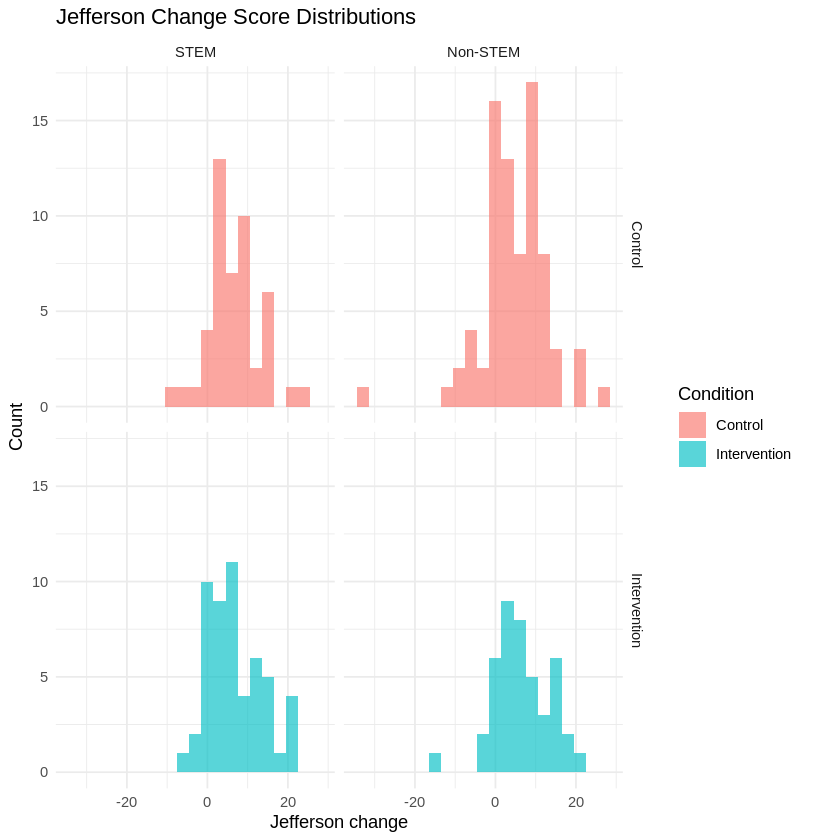

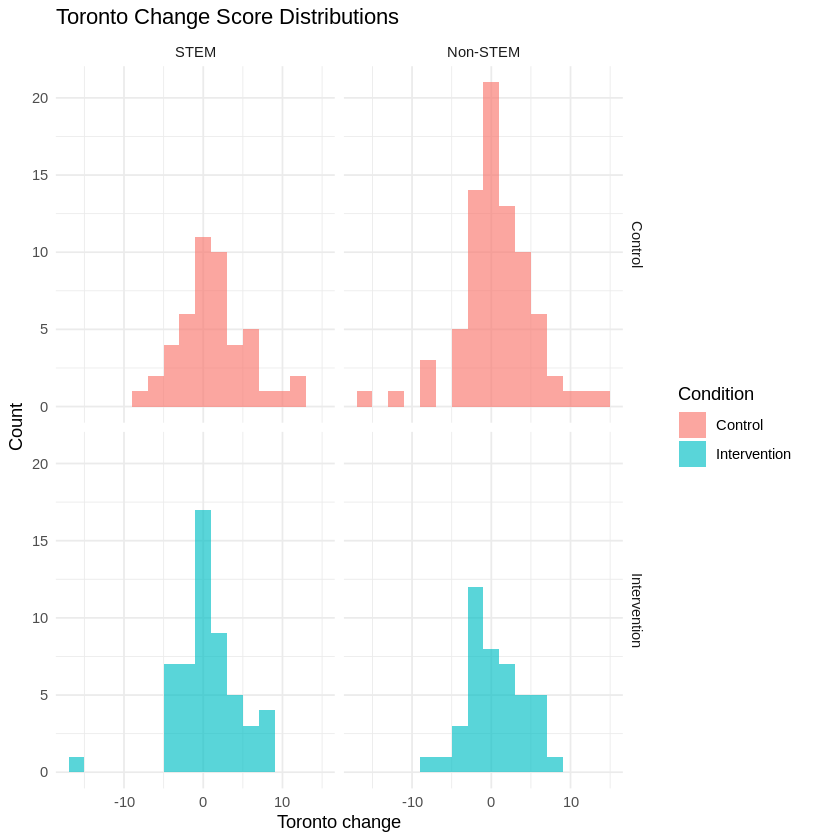

In [ ]:
ggplot(matched_change, aes(x = J_change, fill = Condition)) +
  geom_histogram(binwidth = 3, alpha = 0.65, position = "identity") +
  facet_grid(Condition ~ STEM) +
  labs(title = "Jefferson Change Score Distributions", x = "Jefferson change", y = "Count") +
  theme_minimal()

ggplot(matched_change, aes(x = T_change, fill = Condition)) +
  geom_histogram(binwidth = 2, alpha = 0.65, position = "identity") +
  facet_grid(Condition ~ STEM) +
  labs(title = "Toronto Change Score Distributions", x = "Toronto change", y = "Count") +
  theme_minimal()

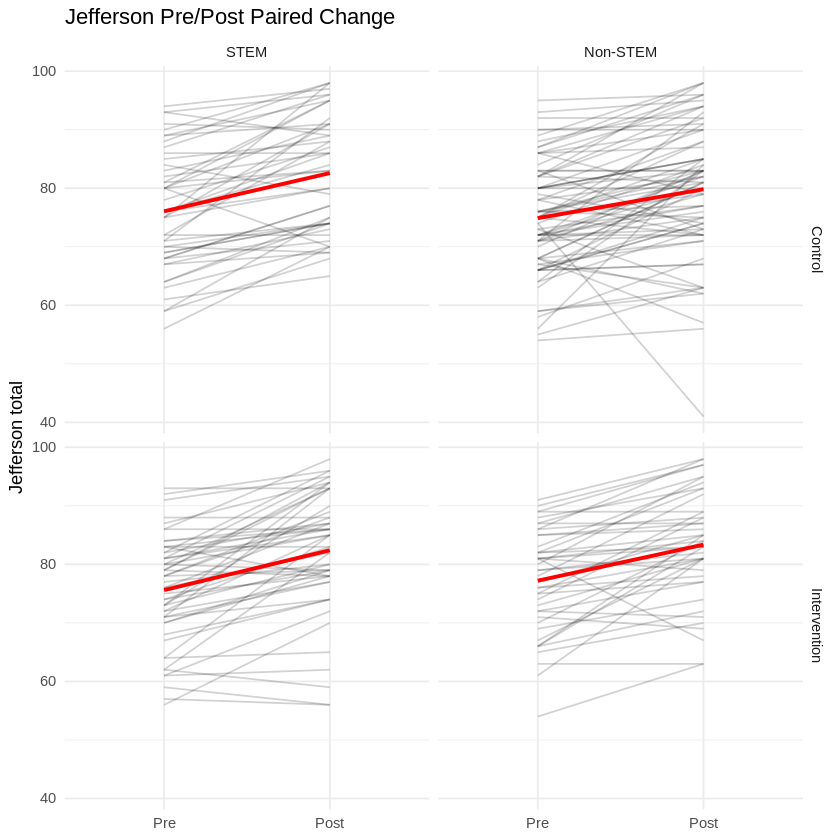

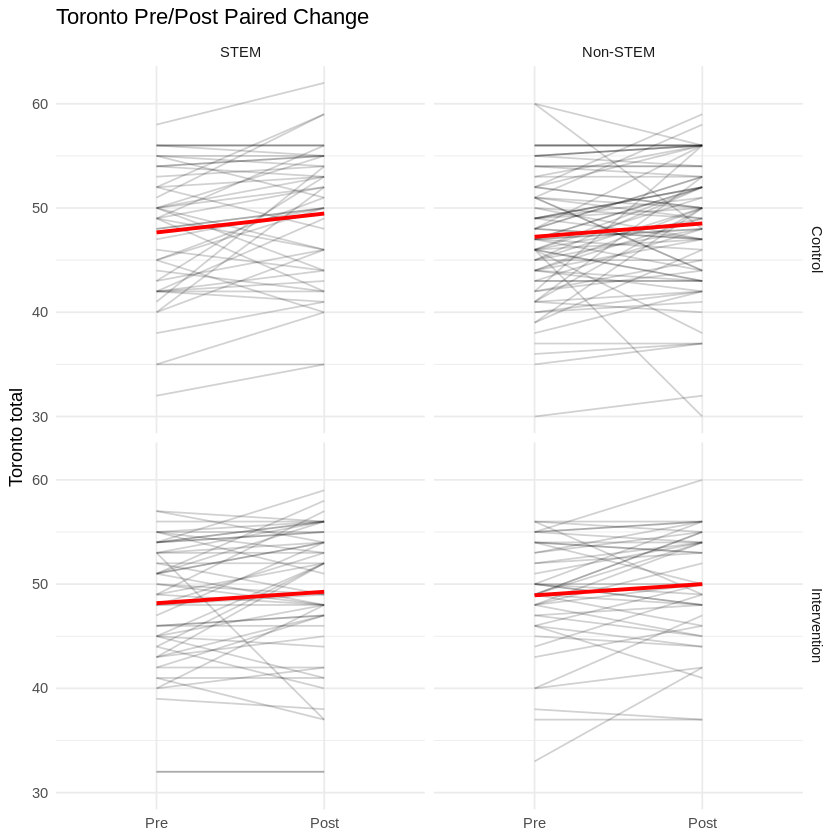

In [ ]:
ggplot(survey_clean, aes(x = Survey, y = J_total, group = `DID #`)) +
  geom_line(alpha = 0.18) +
  stat_summary(aes(group = 1), fun = mean, geom = "line", linewidth = 1.1, color = "red") +
  facet_grid(Condition ~ STEM) +
  labs(title = "Jefferson Pre/Post Paired Change", x = NULL, y = "Jefferson total") +
  theme_minimal()

ggplot(survey_clean, aes(x = Survey, y = T_total, group = `DID #`)) +
  geom_line(alpha = 0.18) +
  stat_summary(aes(group = 1), fun = mean, geom = "line", linewidth = 1.1, color = "red") +
  facet_grid(Condition ~ STEM) +
  labs(title = "Toronto Pre/Post Paired Change", x = NULL, y = "Toronto total") +
  theme_minimal()


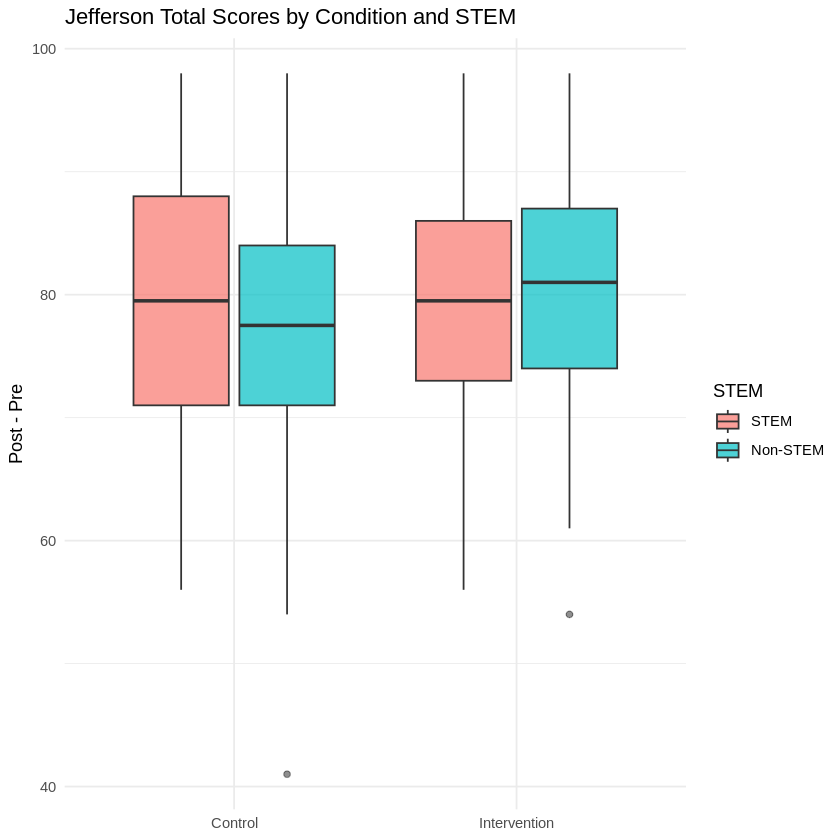

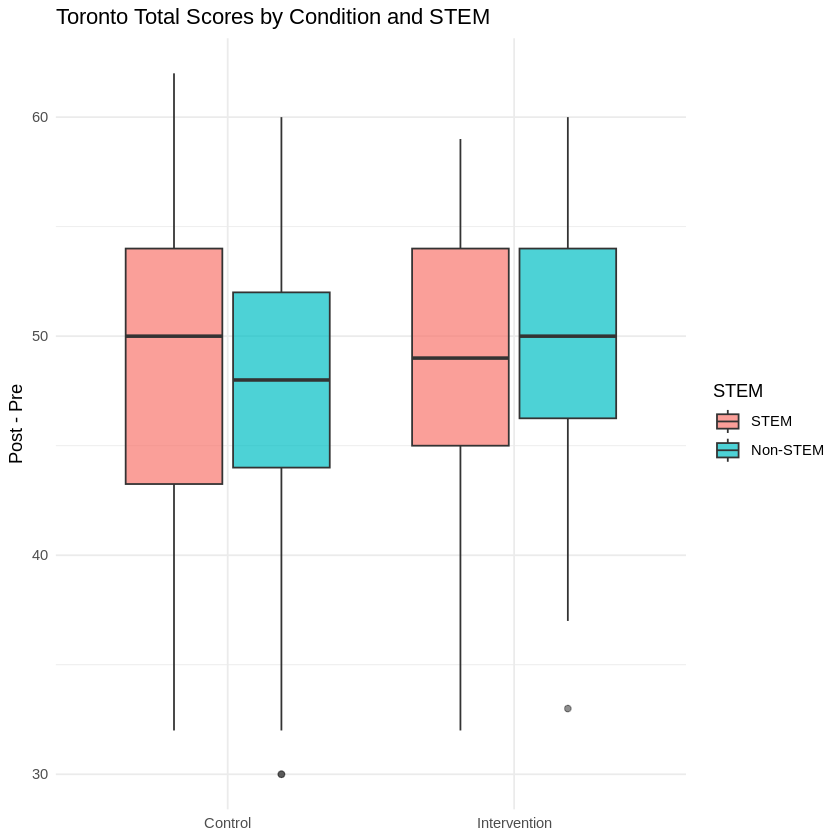

In [ ]:
ggplot(survey_clean, aes(x = Condition, y = J_total, fill = STEM)) +
  geom_boxplot(alpha = 0.7, outlier.alpha = 0.55) +
  labs(title = "Jefferson Total Scores by Condition and STEM", x = NULL, y = "Post - Pre") +
  theme_minimal()

ggplot(survey_clean, aes(x = Condition, y = T_total, fill = STEM)) +
  geom_boxplot(alpha = 0.7, outlier.alpha = 0.55) +
  labs(title = "Toronto Total Scores by Condition and STEM", x = NULL, y = "Post - Pre") +
  theme_minimal()

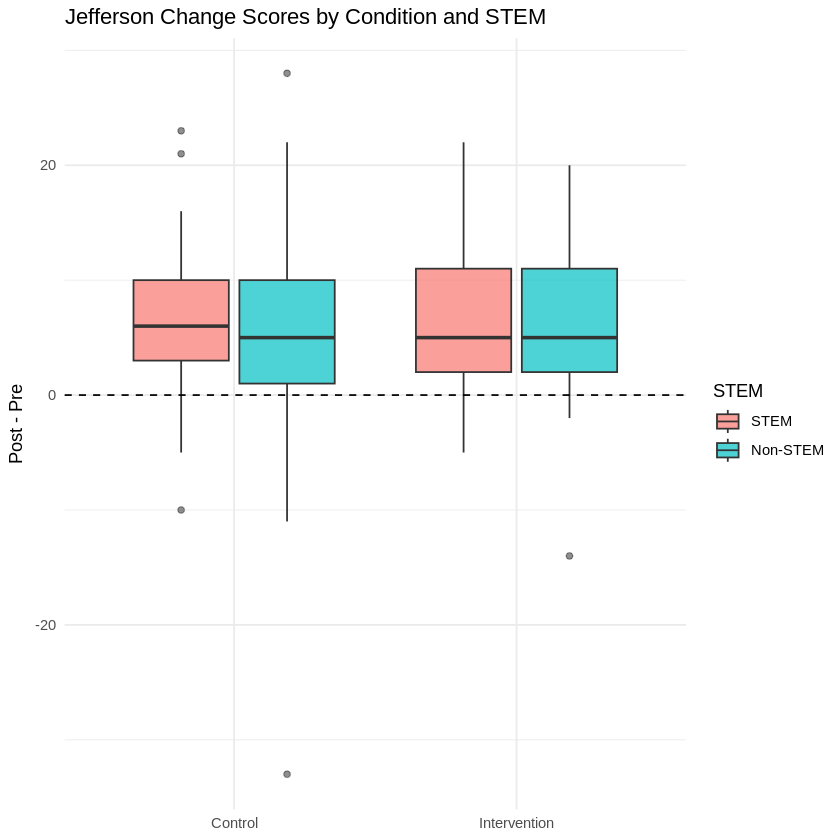

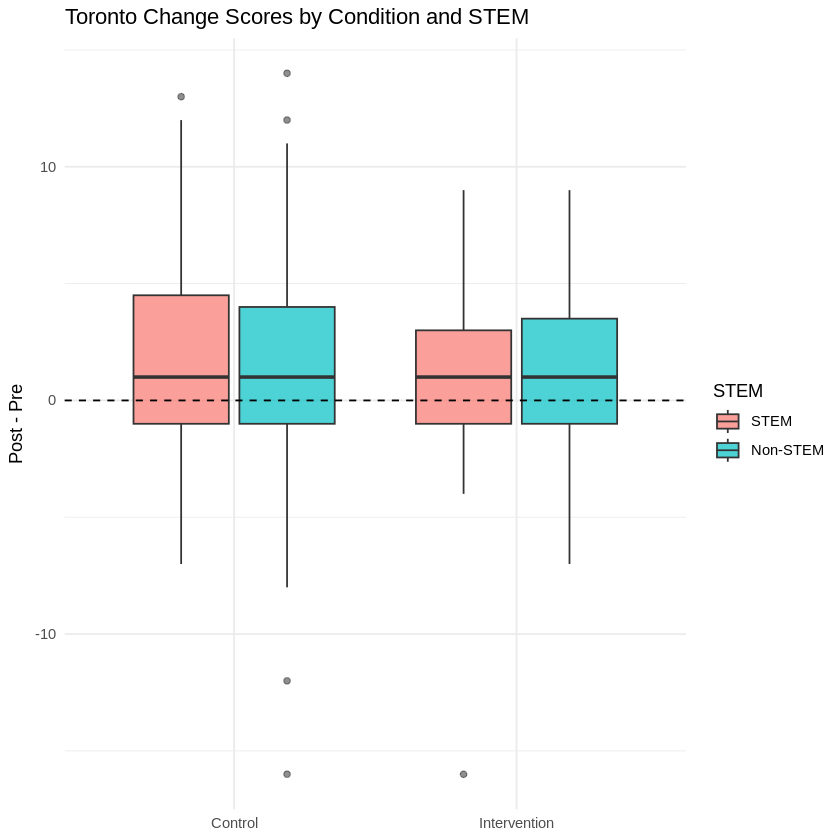

In [ ]:
ggplot(matched_change, aes(x = Condition, y = J_change, fill = STEM)) +
  geom_boxplot(alpha = 0.7, outlier.alpha = 0.55) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(title = "Jefferson Change Scores by Condition and STEM", x = NULL, y = "Post - Pre") +
  theme_minimal()

ggplot(matched_change, aes(x = Condition, y = T_change, fill = STEM)) +
  geom_boxplot(alpha = 0.7, outlier.alpha = 0.55) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(title = "Toronto Change Scores by Condition and STEM", x = NULL, y = "Post - Pre") +
  theme_minimal()


## Residual, Fitted, and Q-Q Diagnostics

These diagnostics are shown for the primary factorial change-score models and baseline STEM comparison models.


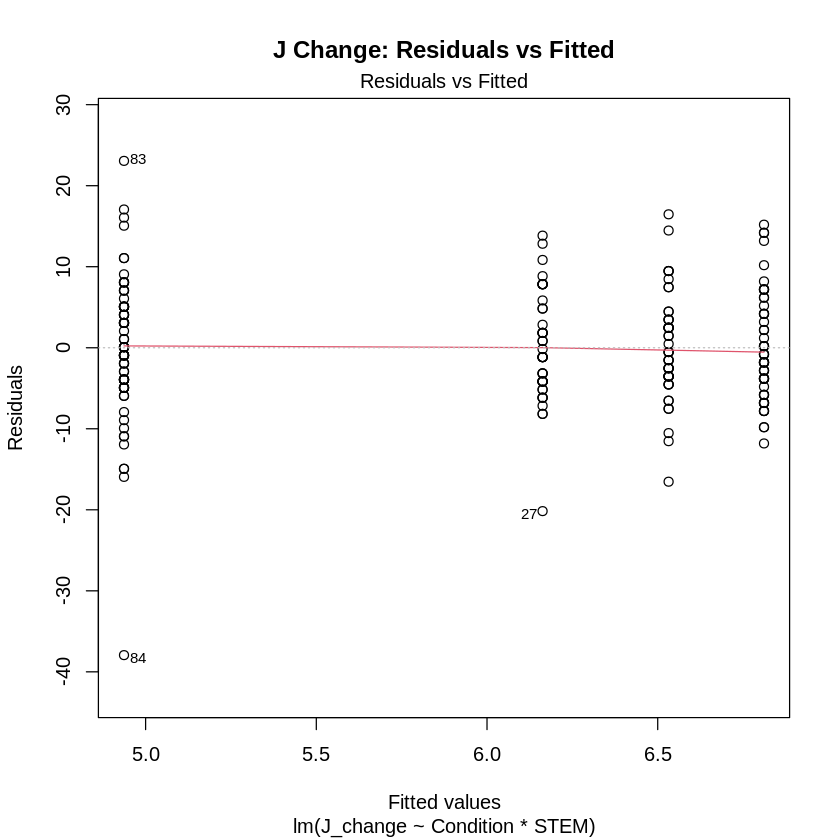

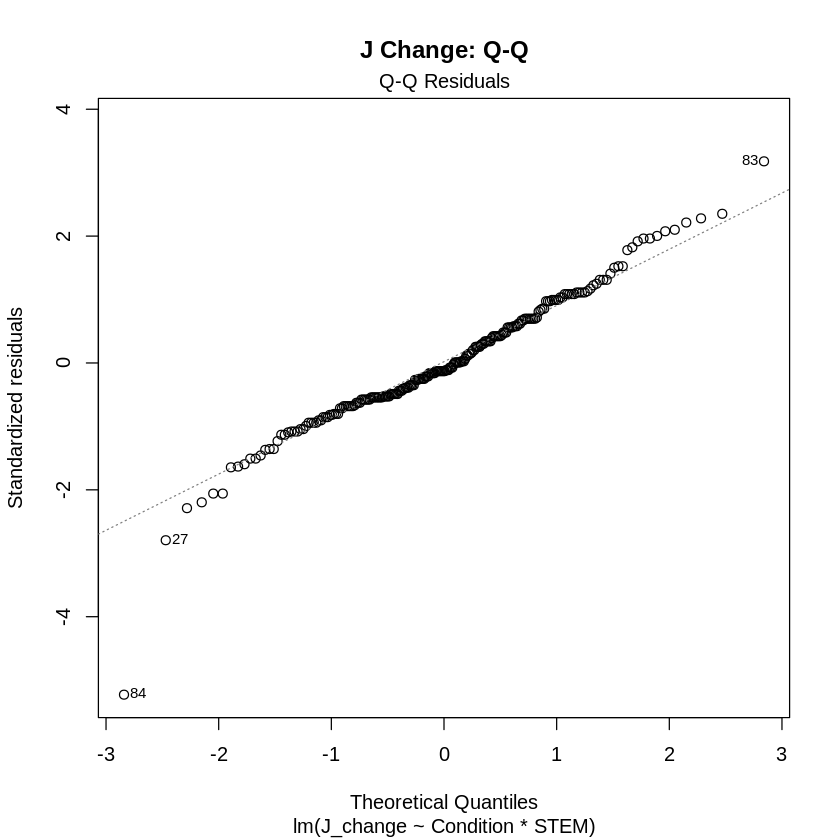

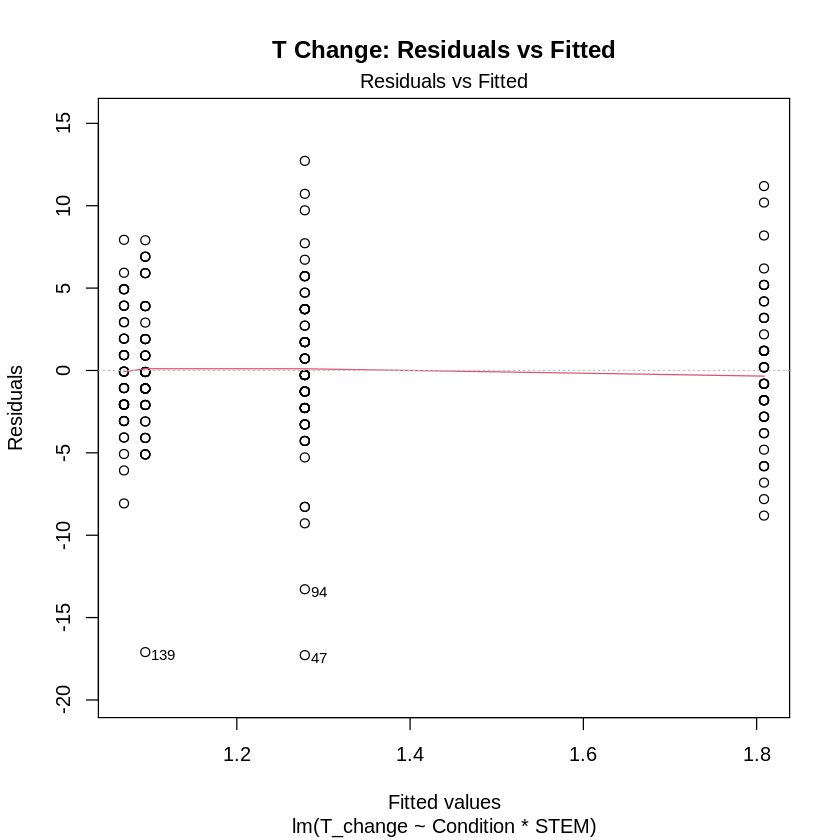

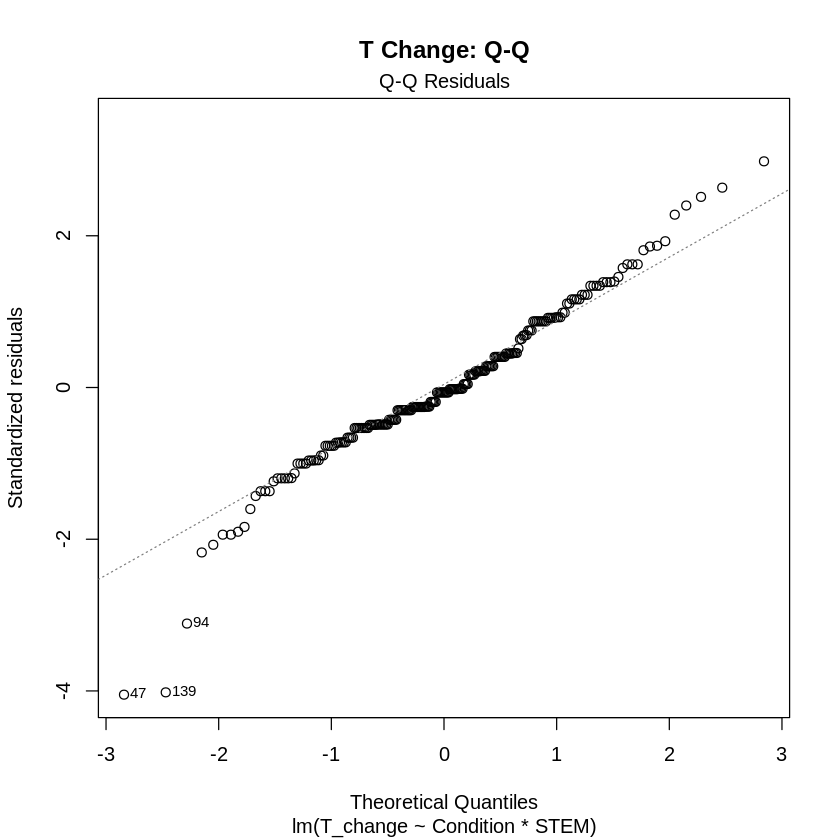

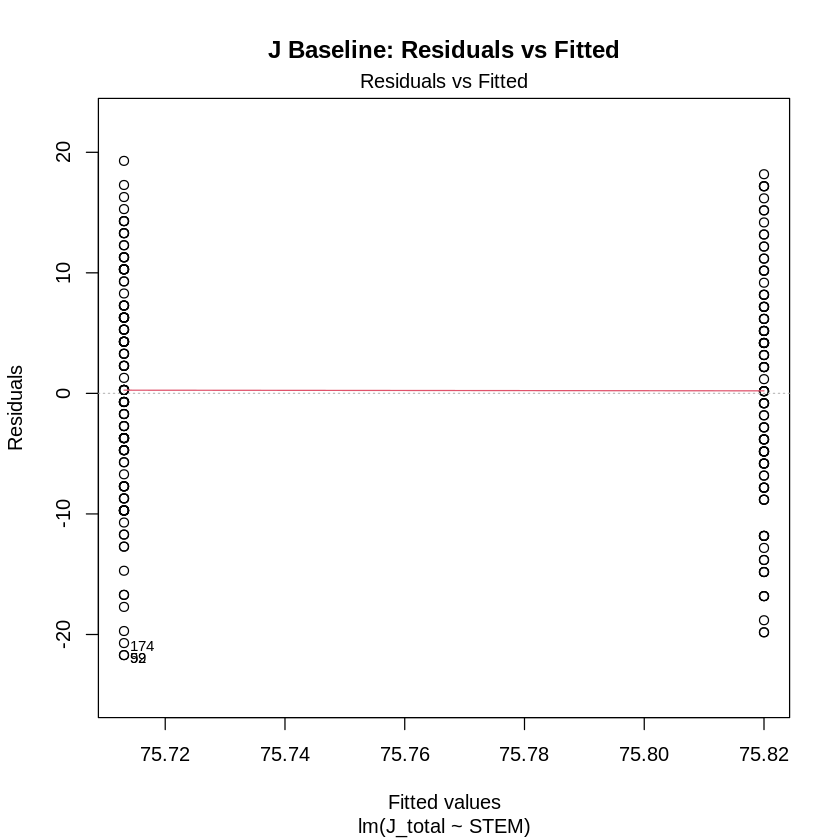

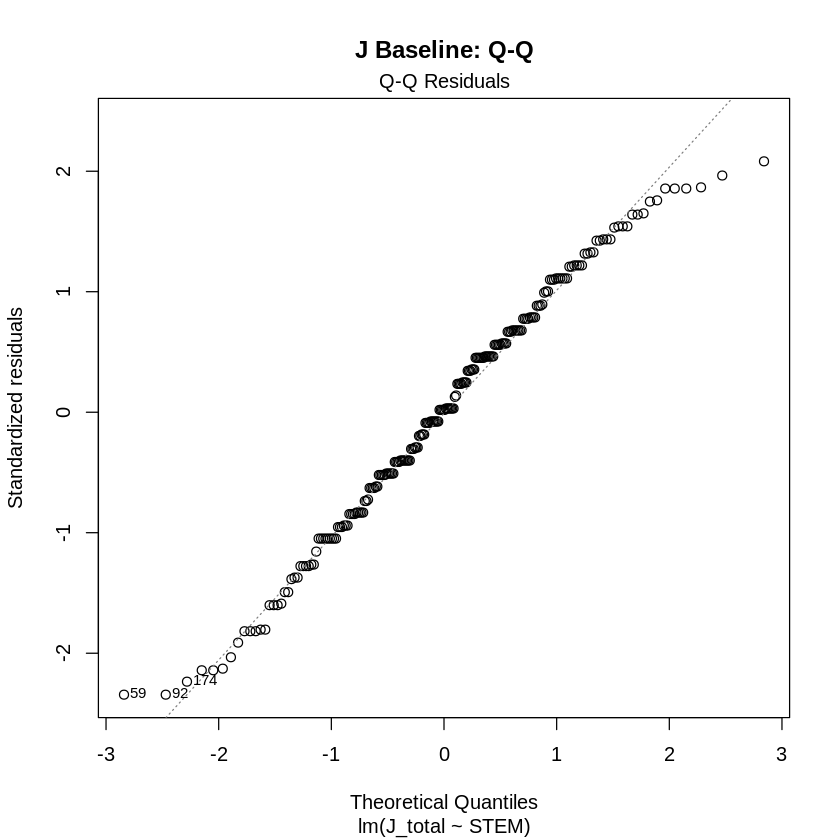

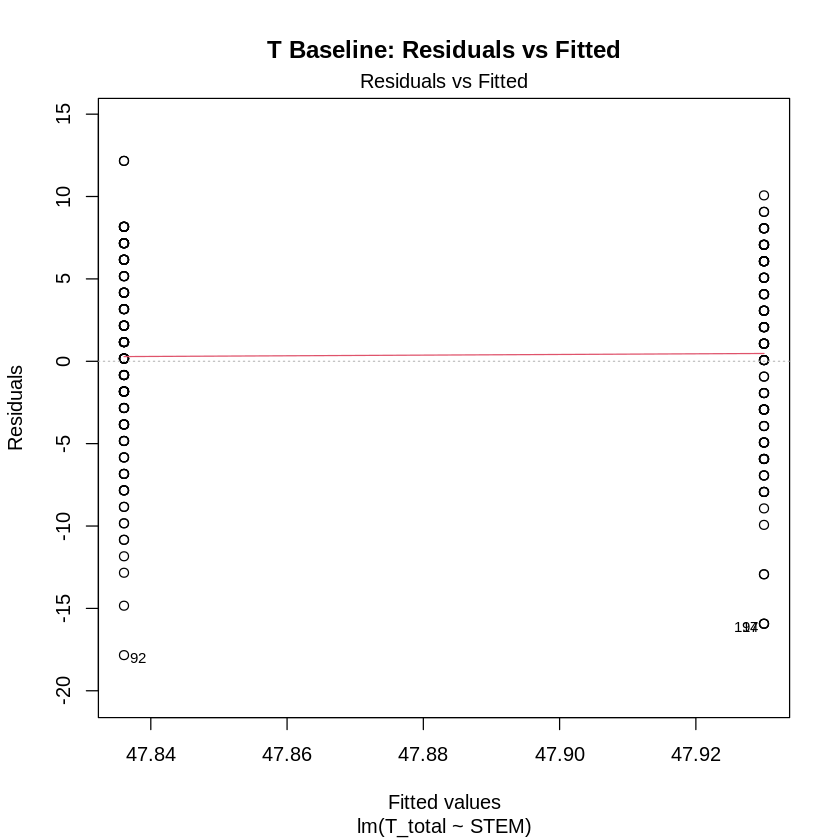

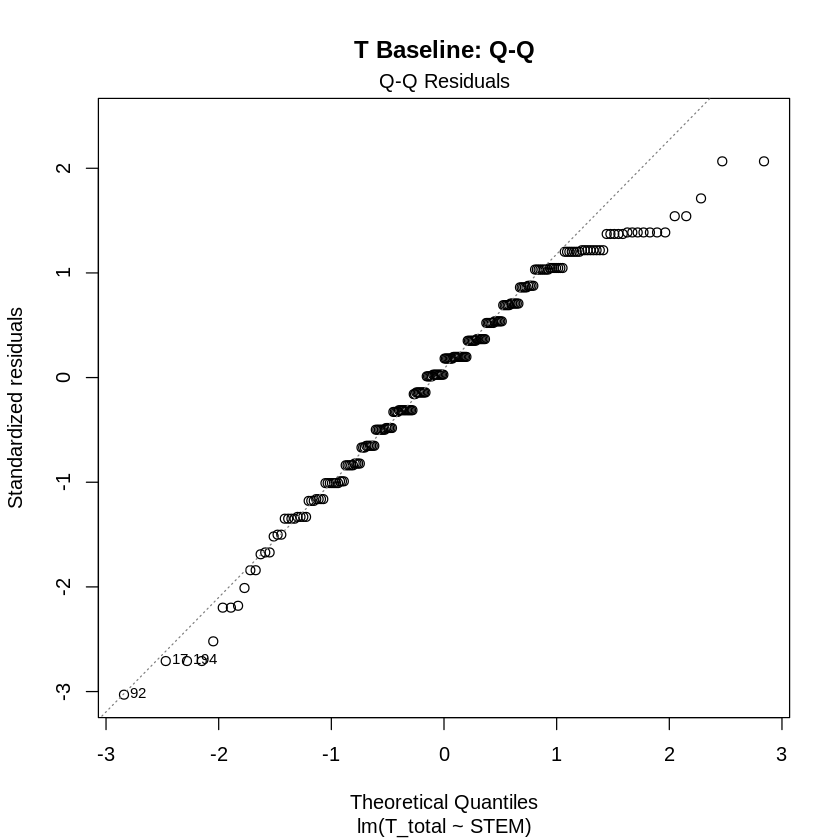

In [ ]:
 J_change_model <- lm(J_change ~ Condition * STEM, data = matched_change)
T_change_model <- lm(T_change ~ Condition * STEM, data = matched_change)

J_baseline_model <- lm(J_total ~ STEM, data = pre_survey_clean)
T_baseline_model <- lm(T_total ~ STEM, data = pre_survey_clean)

par(mfrow = c(2, 2))
plot(J_change_model, which = 1, main = "J Change: Residuals vs Fitted")
plot(J_change_model, which = 2, main = "J Change: Q-Q")
plot(T_change_model, which = 1, main = "T Change: Residuals vs Fitted")
plot(T_change_model, which = 2, main = "T Change: Q-Q")
par(mfrow = c(1, 1))

par(mfrow = c(2, 2))
plot(J_baseline_model, which = 1, main = "J Baseline: Residuals vs Fitted")
plot(J_baseline_model, which = 2, main = "J Baseline: Q-Q")
plot(T_baseline_model, which = 1, main = "T Baseline: Residuals vs Fitted")
plot(T_baseline_model, which = 2, main = "T Baseline: Q-Q")
par(mfrow = c(1, 1))


## Numerical Assumption Checks


In [ ]:
assumption_tests <- list(
  shapiro_J_change_residuals = shapiro.test(residuals(J_change_model)),
  shapiro_T_change_residuals = shapiro.test(residuals(T_change_model)),
  shapiro_J_baseline_residuals = shapiro.test(residuals(J_baseline_model)),
  shapiro_T_baseline_residuals = shapiro.test(residuals(T_baseline_model)),
  variance_J_change_by_condition = var.test(J_change ~ Condition, data = matched_change),
  variance_T_change_by_condition = var.test(T_change ~ Condition, data = matched_change),
  variance_J_change_by_STEM = var.test(J_change ~ STEM, data = matched_change),
  variance_T_change_by_STEM = var.test(T_change ~ STEM, data = matched_change),
  bartlett_J_change_condition_stem = bartlett.test(J_change ~ interaction(Condition, STEM), data = matched_change),
  bartlett_T_change_condition_stem = bartlett.test(T_change ~ interaction(Condition, STEM), data = matched_change)
)

assumption_tests


$shapiro_J_change_residuals

	Shapiro-Wilk normality test

data:  residuals(J_change_model)
W = 0.96367, p-value = 1.898e-05


$shapiro_T_change_residuals

	Shapiro-Wilk normality test

data:  residuals(T_change_model)
W = 0.96508, p-value = 2.811e-05


$shapiro_J_baseline_residuals

	Shapiro-Wilk normality test

data:  residuals(J_baseline_model)
W = 0.98699, p-value = 0.04046


$shapiro_T_baseline_residuals

	Shapiro-Wilk normality test

data:  residuals(T_baseline_model)
W = 0.9732, p-value = 0.0003181


$variance_J_change_by_condition

	F test to compare two variances

data:  J_change by Condition
F = 1.3717, num df = 125, denom df = 95, p-value = 0.1064
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 0.9340512 1.9944707
sample estimates:
ratio of variances 
          1.371687 


$variance_T_change_by_condition

	F test to compare two variances

data:  T_change by Condition
F = 1.4095, num df = 125, denom df = 95, p-value = 0.07972

## Ceiling-Effect Checks



Call:
lm(formula = J_change ~ J_pre, data = matched_change)

Residuals:
    Min      1Q  Median      3Q     Max 
-39.287  -3.833  -0.779   4.639  18.370 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 20.03020    3.93032   5.096 7.45e-07 ***
J_pre       -0.18572    0.05149  -3.607 0.000384 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.104 on 220 degrees of freedom
Multiple R-squared:  0.05583,	Adjusted R-squared:  0.05154 
F-statistic: 13.01 on 1 and 220 DF,  p-value: 0.0003838



Call:
lm(formula = T_change ~ T_pre, data = matched_change)

Residuals:
     Min       1Q   Median       3Q      Max 
-17.7172  -2.5688   0.1422   2.4000  11.4078 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 11.77996    2.24686   5.243 3.70e-07 ***
T_pre       -0.21876    0.04658  -4.697 4.66e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.084 on 220 degrees of freedom
Multiple R-squared:  0.09113,	Adjusted R-squared:  0.08699 
F-statistic: 22.06 on 1 and 220 DF,  p-value: 4.658e-06


[1] -0.236278

[1] -0.3018693

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


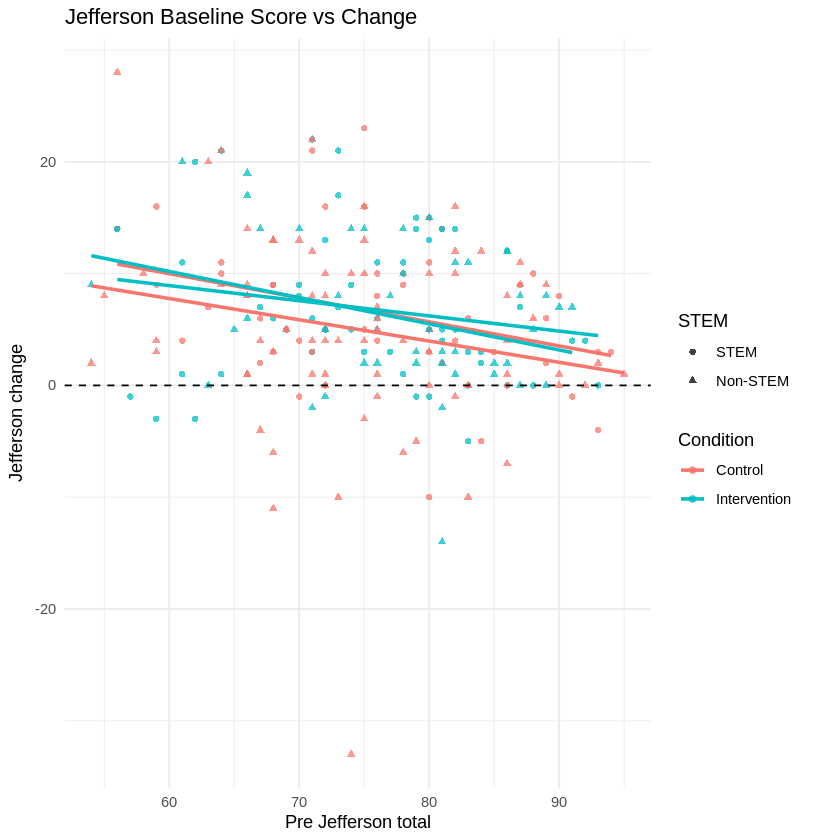

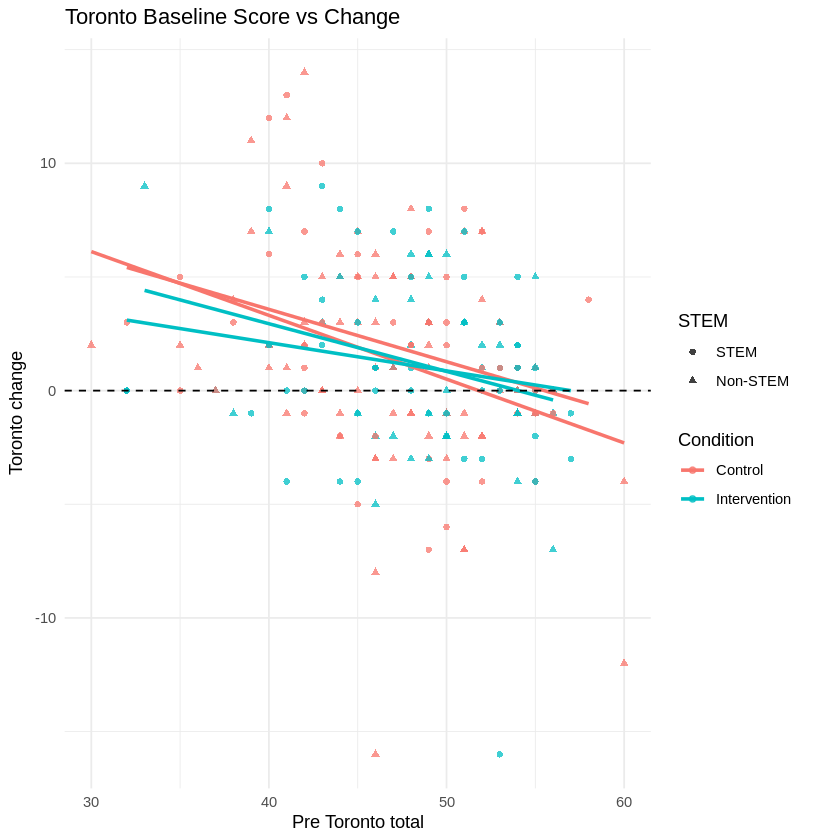

In [ ]:
J_ceiling_model <- lm(J_change ~ J_pre, data = matched_change)
T_ceiling_model <- lm(T_change ~ T_pre, data = matched_change)

summary(J_ceiling_model)
summary(T_ceiling_model)

cor(matched_change$J_pre, matched_change$J_change, use = "complete.obs")
cor(matched_change$T_pre, matched_change$T_change, use = "complete.obs")

ggplot(matched_change, aes(x = J_pre, y = J_change, color = Condition, shape = STEM)) +
  geom_point(alpha = 0.75) +
  geom_smooth(method = "lm", se = FALSE) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(title = "Jefferson Baseline Score vs Change", x = "Pre Jefferson total", y = "Jefferson change") +
  theme_minimal()

ggplot(matched_change, aes(x = T_pre, y = T_change, color = Condition, shape = STEM)) +
  geom_point(alpha = 0.75) +
  geom_smooth(method = "lm", se = FALSE) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(title = "Toronto Baseline Score vs Change", x = "Pre Toronto total", y = "Toronto change") +
  theme_minimal()
